Step 1: Import Necessary Libraries


In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Ensure GPU is being used
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("Using GPU")
else:
    print("No GPU found, using CPU")

Using GPU


Step 2: Load and Explore the Data


In [3]:
# Define paths to the dataset
train_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train'
val_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/val'
test_dir = '/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/test'

In [4]:
# List all the classes (animal types)
classes = os.listdir(train_dir)
num_classes = len(classes)

# Display the number of classes and some sample images
print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

Number of classes: 2
Classes: ['nofire', 'fire']


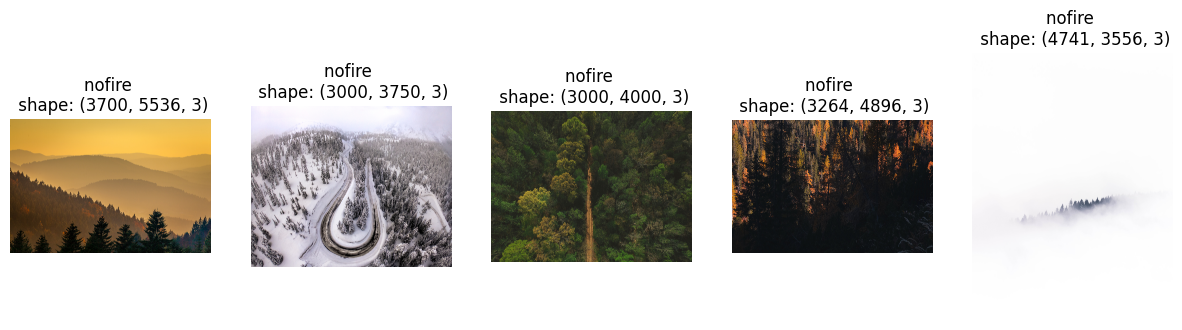

In [5]:
# Visualize some images from the dataset
plt.figure(figsize=(15, 10))
for i in range(5):
    class_path = os.path.join(train_dir, classes[0])
    img_name = os.listdir(class_path)[i]
    img_path = os.path.join(class_path, img_name)
    img = plt.imread(img_path)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"{classes[0]} \n shape: {img.shape}")
    plt.axis('off')
plt.show()

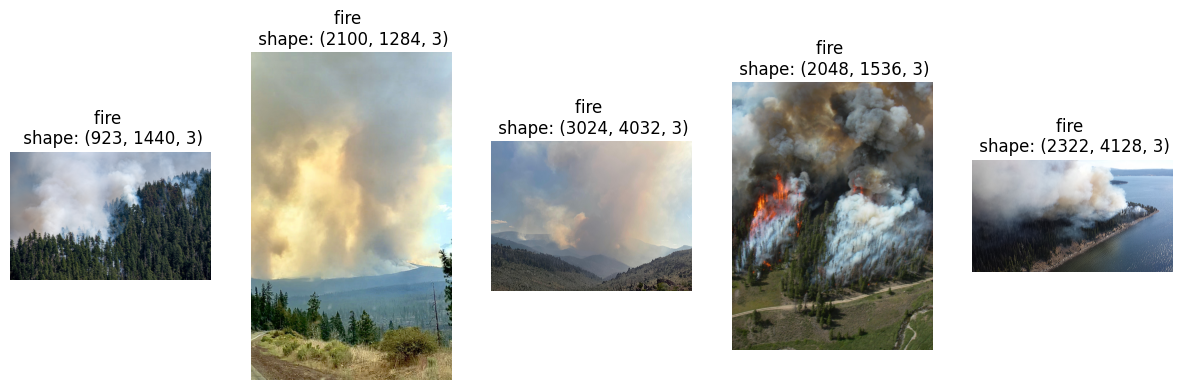

In [6]:
# Visualize some images from the dataset
plt.figure(figsize=(15, 10))
for i in range(5):
    class_path = os.path.join(train_dir, classes[1])
    img_name = os.listdir(class_path)[i]
    img_path = os.path.join(class_path, img_name)
    img = plt.imread(img_path)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"{classes[1]} \n shape: {img.shape}")
    plt.axis('off')
plt.show()

In [7]:

# Image dimensions and batch size
img_width, img_height = 150, 150
batch_size = 32

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True)

Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.


In [8]:
# Access the class-to-index mapping
class_mapping = train_generator.class_indices
# Extract class names
class_names = list(class_mapping.keys())
print("Class names:", class_names)

Class names: ['fire', 'nofire']


Step 3: Build the CNN Model


In [9]:
model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])



In [10]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

Step 4: Train the Model


In [11]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=30,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size)


Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/58 ━━━━━━━━━━━━━━━━━━━━ 5:48 8s/step - accuracy: 0.5292 - loss: 0.8276

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


15/58 ━━━━━━━━━━━━━━━━━━━━ 5:39 8s/step - accuracy: 0.5368 - loss: 0.8144

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


58/58 ━━━━━━━━━━━━━━━━━━━━ 569s 9s/step - accuracy: 0.6093 - loss: 0.6892 - val_accuracy: 0.7474 - val_loss: 0.5037
Epoch 2/30
 1/58 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8438 - loss: 0.4557

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8438 - loss: 0.4557 - val_accuracy: 0.6667 - val_loss: 0.5032
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 426s 7s/step - accuracy: 0.7702 - loss: 0.5016 - val_accuracy: 0.7500 - val_loss: 0.5090
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.6875 - loss: 0.6563 - val_accuracy: 0.7222 - val_loss: 0.5147
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 423s 6s/step - accuracy: 0.7728 - loss: 0.4815 - val_accuracy: 0.7786 - val_loss: 0.4427
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7812 - loss: 0.3765 - val_accuracy: 0.6667 - val_loss: 0.4910
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 441s 7s/step - accuracy: 0.8065 - loss: 0.4281 - val_accuracy: 0.7422 - val_loss: 0.5272
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7500 - loss: 0.4989 - val_accuracy: 0.7222 - val_loss: 0.6867
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 469s 7s/step - accuracy: 0.7994 - loss: 0.4436 - val_accuracy: 0.7891 - val_loss: 0.

Step 5: Evaluate the Model


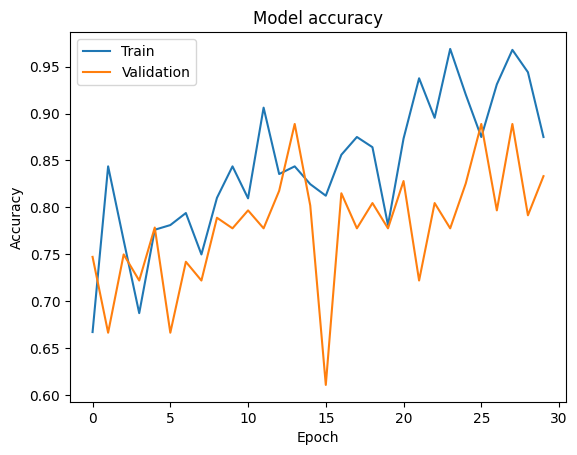

In [12]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


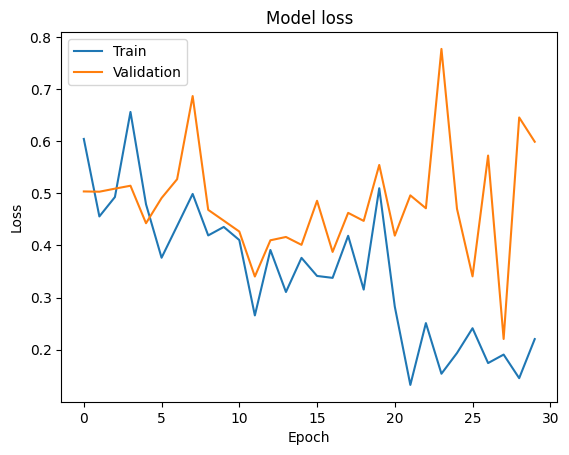

In [13]:

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [14]:
# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f'Test accuracy: {test_acc:.4f}')


 5/12 ━━━━━━━━━━━━━━━━━━━━ 1:00 9s/step - accuracy: 0.7919 - loss: 0.6353

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 9/12 ━━━━━━━━━━━━━━━━━━━━ 27s 9s/step - accuracy: 0.7903 - loss: 0.6102

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3406: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 110s 9s/step - accuracy: 0.7917 - loss: 0.5809
Test accuracy: 0.7969


Step 6: Save the Model


In [15]:
model.save('/kaggle/working/forest_fire_detection_model.keras')


Step 7: Load and Predict Using the Model


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the model
model = load_model('/kaggle/working/forest_fire_detection_model.keras')

# Predict on new images
def predict_animal(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    
    prediction = model.predict(img_array)
    if prediction > 0.5:
        predicted_class = class_names[1]
    else:
        predicted_class = class_names[0]
    
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step


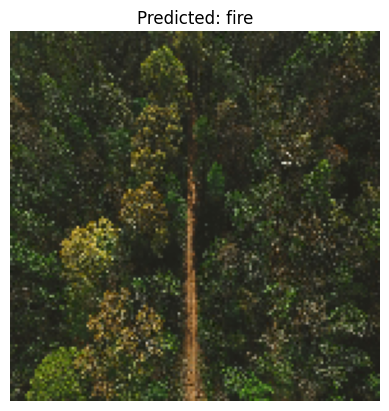

In [17]:
predict_animal("/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/nofire/ozark-drones-H1psDNcpOfI-unsplash.jpg")

In [18]:
os.listdir("/kaggle/input/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/nofire")

['maciek-sulkowski-oCmOCNGJM1g-unsplash.jpg',
 'bobby-stevenson-Bi8vaFCoaNM-unsplash.jpg',
 'ozark-drones-H1psDNcpOfI-unsplash.jpg',
 'cristina-gottardi-ahzgaalmLYY-unsplash.jpg',
 'mads-schmidt-rasmussen-6YmzwamGzCg-unsplash.jpg',
 'harald-pliessnig-fI_UmufdnX4-unsplash.jpg',
 'matt-palmer-P2zKezpWLwY-unsplash.jpg',
 'jim-niakaris-4BIQP4swrSE-unsplash.jpg',
 'eberhard-grossgasteiger-RVj002xHssw-unsplash.jpg',
 'johny-goerend-pK8Wj_wZVkw-unsplash.jpg',
 'nic-y-c-vNBg-a6eRtc-unsplash.jpg',
 'olena-sergienko-0Ws_-v4Y_wY-unsplash.jpg',
 '35581717623_efaaaf5821_o.jpg',
 '36321782572_3aa9b4fc64_o.jpg',
 'marek-piwnicki-WElEec96cxk-unsplash.jpg',
 'aaron-burden-qqH0Clj6OFE-unsplash.jpg',
 'matthew-6abeLGdk-jo-unsplash.jpg',
 'benjamin-voros-t-3f5RS-JGI-unsplash.jpg',
 '23905687626_75ac1e721d_o.jpg',
 'kristaps-ungurs-UIOmH4F3Wtk-unsplash.jpg',
 'kym-mackinnon-ohRlkFvO5e8-unsplash.jpg',
 '39728610281_68e77869f2_o.jpg',
 'kevin-fitzgerald-8ji8O5uHE1U-unsplash.jpg',
 'luke-baard-DdNyljNFYX4-uns